<a href="https://colab.research.google.com/github/AvikRaj/insurance-fraud-detection-pipeline/blob/main/notebooks/pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import pandas as pd
import numpy as np
import kagglehub
from kagglehub import KaggleDatasetAdapter
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
print("All imports completed")


All imports completed


In [2]:
# Set the path to the file you'd like to load
file_path = "insurance_claims.csv" # Changed from "/content/insurance_claims.csv"

# Load the latest version
df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "buntyshah/auto-insurance-claims-data",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

# Display the total number of rows and columns
print(f"Dataset Shape: {df.shape}")
print("-" * 30)

# Display the first 5 rows to understand the feature formats
print("First 5 records:")
display(df.head())

# Display data types and non-null counts to identify missing values
print("Data set Info:")
df.info()

100%|██████████| 261k/261k [00:00<00:00, 19.2MB/s]

Dataset Shape: (1000, 40)
------------------------------
First 5 records:


,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,...,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported,_c39
0,328,48,521585,2014-10-17,OH,250/500,1000,1406.91,0,466132,...,YES,71610,6510,13020,52080,Saab,92x,2004,Y,NaN
1,228,42,342868,2006-06-27,IN,250/500,2000,1197.22,5000000,468176,...,?,5070,780,780,3510,Mercedes,E400,2007,Y,NaN
2,134,29,687698,2000-09-06,OH,100/300,2000,1413.14,5000000,430632,...,NO,34650,7700,3850,23100,Dodge,RAM,2007,N,NaN
3,256,41,227811,1990-05-25,IL,250/500,2000,1415.74,6000000,608117,...,NO,63400,6340,6340,50720,Chevrolet,Tahoe,2014,Y,NaN
4,228,44,367455,2014-06-06,IL,500/1000,1000,1583.91,6000000,610706,...,NO,6500,1300,650,4550,Accura,RSX,2009,N,NaN


Data set Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 40 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   months_as_customer           1000 non-null   int64  
 1   age                          1000 non-null   int64  
 2   policy_number                1000 non-null   int64  
 3   policy_bind_date             1000 non-null   object 
 4   policy_state                 1000 non-null   object 
 5   policy_csl                   1000 non-null   object 
 6   policy_deductable            1000 non-null   int64  
 7   policy_annual_premium        1000 non-null   float64
 8   umbrella_limit               1000 non-null   int64  
 9   insured_zip                  1000 non-null   int64  
 10  insured_sex                  1000 non-null   object 
 11  insured_education_level      1000 non-null   object 
 12  insured_occupation           1000 non-null   object 
 13  insu

In [3]:
# ---------------------------------------------------------
# 1. Display Summary Statistics
# ---------------------------------------------------------
print("--- Numerical Summary Statistics ---")
display(df.describe())

print("\n--- Categorical Summary Statistics ---")
display(df.describe(include=['object']))

# ---------------------------------------------------------
# 2. Check & Clean Missing Values (including '?' placeholders)
# ---------------------------------------------------------
# Convert '?' placeholders to standard NaN values
df.replace('?', np.nan, inplace=True)

# Drop the '_c39' column as it is entirely empty/NaN and contains no useful information
if '_c39' in df.columns:
    df.drop(columns=['_c39'], inplace=True)
    print("Dropped column '_c39' due to being entirely NaN.")

print("\n--- Missing Value Counts per Column ---")
missing_counts = df.isnull().sum()
print(missing_counts[missing_counts > 0])

# Impute missing values for numeric columns using the median
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f"Imputed numeric column '{col}' with median: {median_val}")

# Impute missing values for categorical columns using the mode
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        mode_val = df[col].mode()[0]
        df[col].fillna(mode_val, inplace=True)
        print(f"Imputed categorical column '{col}' with mode: '{mode_val}'")

# Verify zero missing values remain
assert df.isnull().sum().sum() == 0, "There are still missing values!"
print("\nMissing value handling complete. Total NaNs remaining: 0")

# ---------------------------------------------------------
# 3. Data Normalization (Min-Max Scaling)
# ---------------------------------------------------------
# Select key numerical features to normalize for model stability
scaler = MinMaxScaler()
cols_to_normalize = ['months_as_customer', 'policy_annual_premium', 'total_claim_amount', 'injury_claim', 'property_claim', 'vehicle_claim']

# Create normalized columns with a prefix
normalized_cols = [f"{col}_norm" for col in cols_to_normalize]
df[normalized_cols] = scaler.fit_transform(df[cols_to_normalize])

print("\n--- Sample Normalized Numerical Features ---")
display(df[normalized_cols].head())

--- Numerical Summary Statistics ---


,months_as_customer,age,policy_number,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,capital-gains,capital-loss,incident_hour_of_the_day,number_of_vehicles_involved,bodily_injuries,witnesses,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_year,_c39
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,0.0
mean,203.954000,38.948000,546238.648000,1136.000000,1256.406150,1.101000e+06,501214.488000,25126.100000,-26793.700000,11.644000,1.83900,0.992000,1.487000,52761.94000,7433.420000,7399.570000,37928.950000,2005.103000,NaN
std,115.113174,9.140287,257063.005276,611.864673,244.167395,2.297407e+06,71701.610941,27872.187708,28104.096686,6.951373,1.01888,0.820127,1.111335,26401.53319,4880.951853,4824.726179,18886.252893,6.015861,NaN
min,0.000000,19.000000,100804.000000,500.000000,433.330000,-1.000000e+06,430104.000000,0.000000,-111100.000000,0.000000,1.00000,0.000000,0.000000,100.00000,0.000000,0.000000,70.000000,1995.000000,NaN
25%,115.750000,32.000000,335980.250000,500.000000,1089.607500,0.000000e+00,448404.500000,0.000000,-51500.000000,6.000000,1.00000,0.000000,1.000000,41812.50000,4295.000000,4445.000000,30292.500000,2000.000000,NaN
50%,199.500000,38.000000,533135.000000,1000.000000,1257.200000,0.000000e+00,466445.500000,0.000000,-23250.000000,12.000000,1.00000,1.000000,1.000000,58055.00000,6775.000000,6750.000000,42100.000000,2005.000000,NaN
75%,276.250000,44.000000,759099.750000,2000.000000,1415.695000,0.000000e+00,603251.000000,51025.000000,0.000000,17.000000,3.00000,2.000000,2.000000,70592.50000,11305.000000,10885.000000,50822.500000,2010.000000,NaN
max,479.000000,64.000000,999435.000000,2000.000000,2047.590000,1.000000e+07,620962.000000,100500.000000,0.000000,23.000000,4.00000,2.000000,3.000000,114920.00000,21450.000000,23670.000000,79560.000000,2015.000000,NaN



--- Categorical Summary Statistics ---


,policy_bind_date,policy_state,policy_csl,insured_sex,insured_education_level,insured_occupation,insured_hobbies,insured_relationship,incident_date,incident_type,...,incident_severity,authorities_contacted,incident_state,incident_city,incident_location,property_damage,police_report_available,auto_make,auto_model,fraud_reported
count,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,...,1000,909,1000,1000,1000,1000,1000,1000,1000,1000
unique,951,3,3,2,7,14,20,6,60,4,...,4,4,7,7,1000,3,3,14,39,2
top,1992-08-05,OH,250/500,FEMALE,JD,machine-op-inspct,reading,own-child,2015-02-02,Multi-vehicle Collision,...,Minor Damage,Police,NY,Springfield,1416 Cherokee Ridge,?,?,Saab,RAM,N
freq,3,352,351,537,161,93,64,183,28,419,...,354,292,262,157,1,360,343,80,43,753


Dropped column '_c39' due to being entirely NaN.

--- Missing Value Counts per Column ---
collision_type             178
authorities_contacted       91
property_damage            360
police_report_available    343
dtype: int64
Imputed categorical column 'collision_type' with mode: 'Rear Collision'
Imputed categorical column 'authorities_contacted' with mode: 'Police'
Imputed categorical column 'property_damage' with mode: 'NO'
Imputed categorical column 'police_report_available' with mode: 'NO'

Missing value handling complete. Total NaNs remaining: 0

--- Sample Normalized Numerical Features ---


/tmp/ipykernel_8023/3668576802.py:38: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(mode_val, inplace=True)


,months_as_customer_norm,policy_annual_premium_norm,total_claim_amount_norm,injury_claim_norm,property_claim_norm,vehicle_claim_norm
0,0.684760,0.603112,0.622801,0.303497,0.550063,0.654296
1,0.475992,0.473214,0.043285,0.036364,0.032953,0.043276
2,0.279749,0.606972,0.300906,0.358974,0.162653,0.289722
3,0.534447,0.608582,0.551298,0.295571,0.267850,0.637187
4,0.475992,0.712760,0.055739,0.060606,0.027461,0.056359


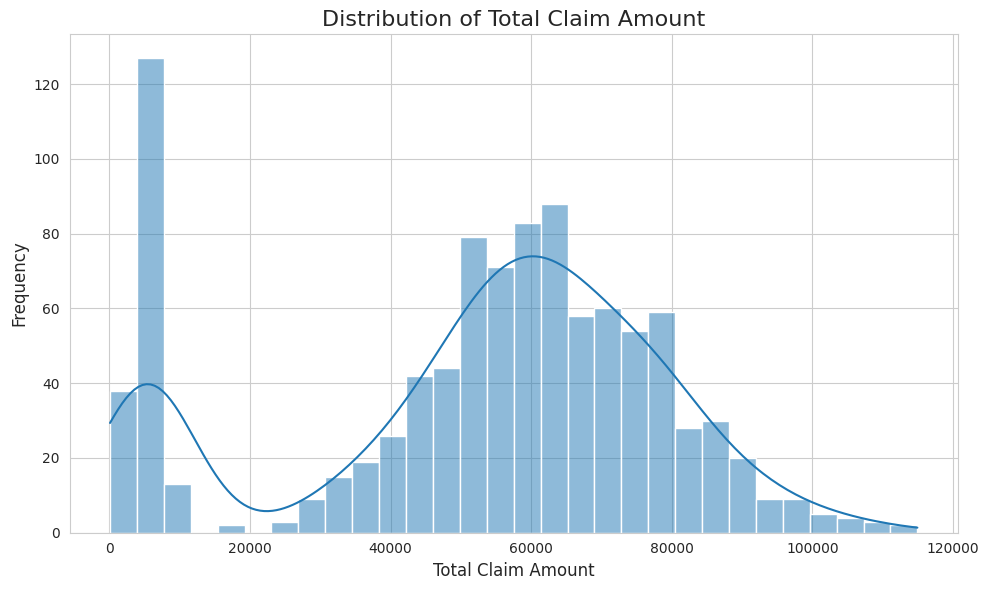

In [4]:
# Set the aesthetic style of the plots
sns.set_style("whitegrid")

# Create a histogram to visualize the distribution of 'total_claim_amount'
plt.figure(figsize=(10, 6))
sns.histplot(df['total_claim_amount'], kde=True, bins=30)
plt.title('Distribution of Total Claim Amount', fontsize=16)
plt.xlabel('Total Claim Amount', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.tight_layout()
plt.show()

This histogram shows the distribution of the `total_claim_amount`. The `kde` (Kernel Density Estimate) line provides a smoothed representation of the distribution. We can observe the range of claim amounts and identify if the distribution is skewed, multimodal, or approximately normal.

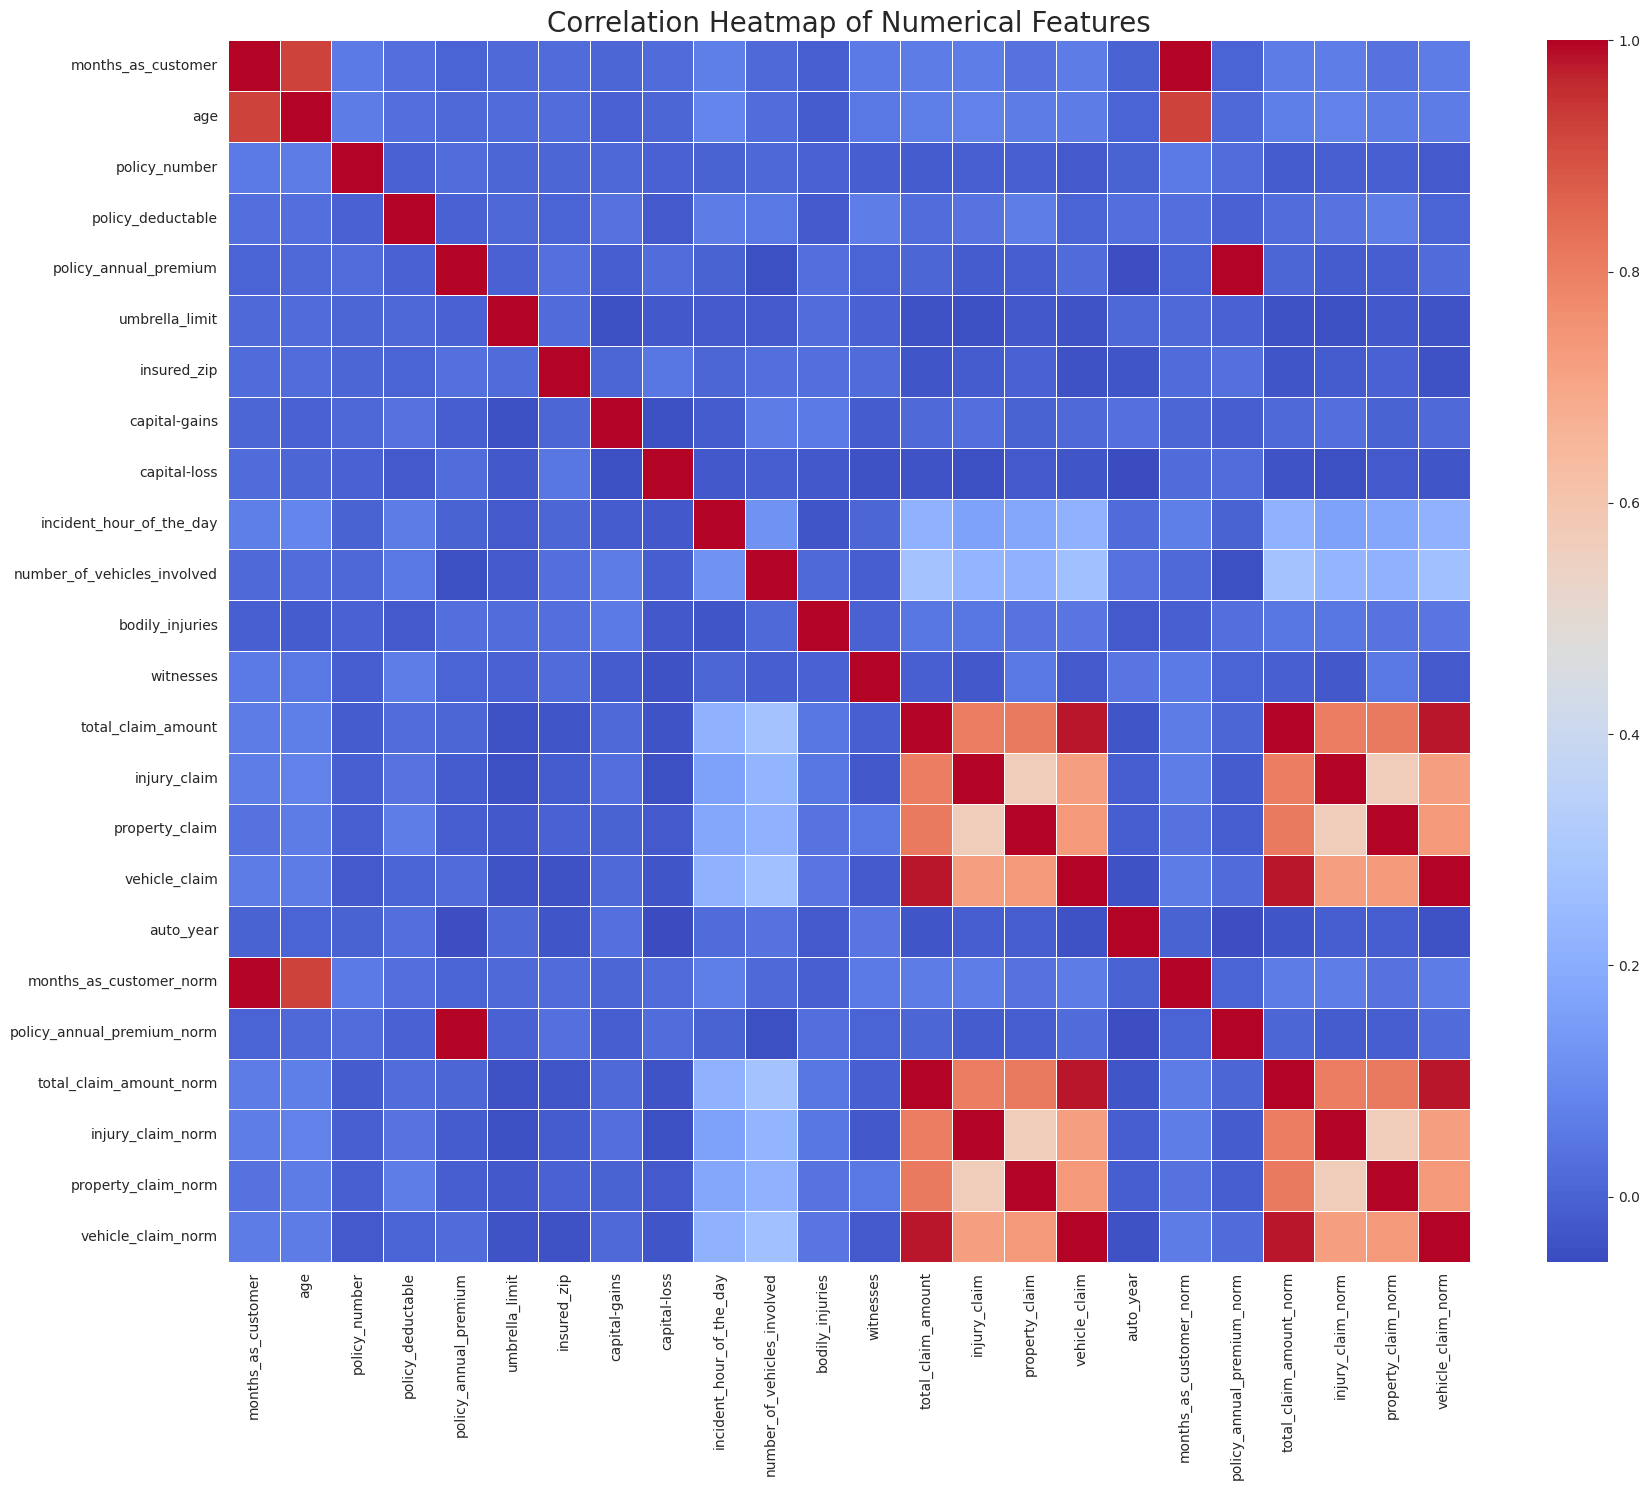

In [5]:
# Select only numerical columns for correlation analysis
numerical_df = df.select_dtypes(include=['int64', 'float64'])

# Calculate the correlation matrix
correlation_matrix = numerical_df.corr()

# Plot the correlation heatmap
plt.figure(figsize=(18, 15)) # Increase figure size for better readability
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Numerical Features', fontsize=20)
plt.xticks(rotation=90) # Rotate x-axis labels for better readability
plt.yticks(rotation=0) # Ensure y-axis labels are horizontal
plt.tight_layout()
plt.show()

This heatmap visualizes the correlation matrix of the numerical features. Each cell in the heatmap represents the Pearson correlation coefficient between two features. Values close to 1 indicate a strong positive correlation, values close to -1 indicate a strong negative correlation, and values close to 0 indicate a weak or no linear correlation. You can adjust `annot=True` if you want to see the correlation values directly on the heatmap, though it might become cluttered with many features.

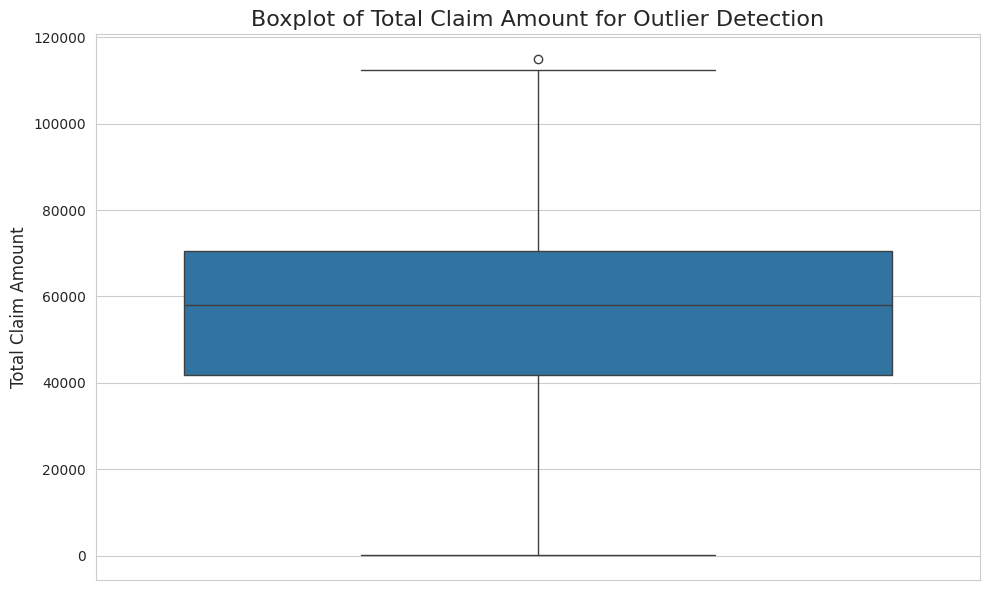

In [6]:
# Create a boxplot to identify outliers in 'total_claim_amount'
plt.figure(figsize=(10, 6))
sns.boxplot(y=df['total_claim_amount'])
plt.title('Boxplot of Total Claim Amount for Outlier Detection', fontsize=16)
plt.ylabel('Total Claim Amount', fontsize=12)
plt.tight_layout()
plt.show()

This boxplot visualizes the distribution of `total_claim_amount` and highlights potential outliers. The box represents the interquartile range (IQR), the line inside the box is the median, and the 'whiskers' extend to the most extreme data points within 1.5 times the IQR from the box. Any points beyond the whiskers are considered outliers.

--- Result of Age Binning ---


,age,age_group
0,48,46-60
1,42,31-45
2,29,18-30
3,41,31-45
4,44,31-45


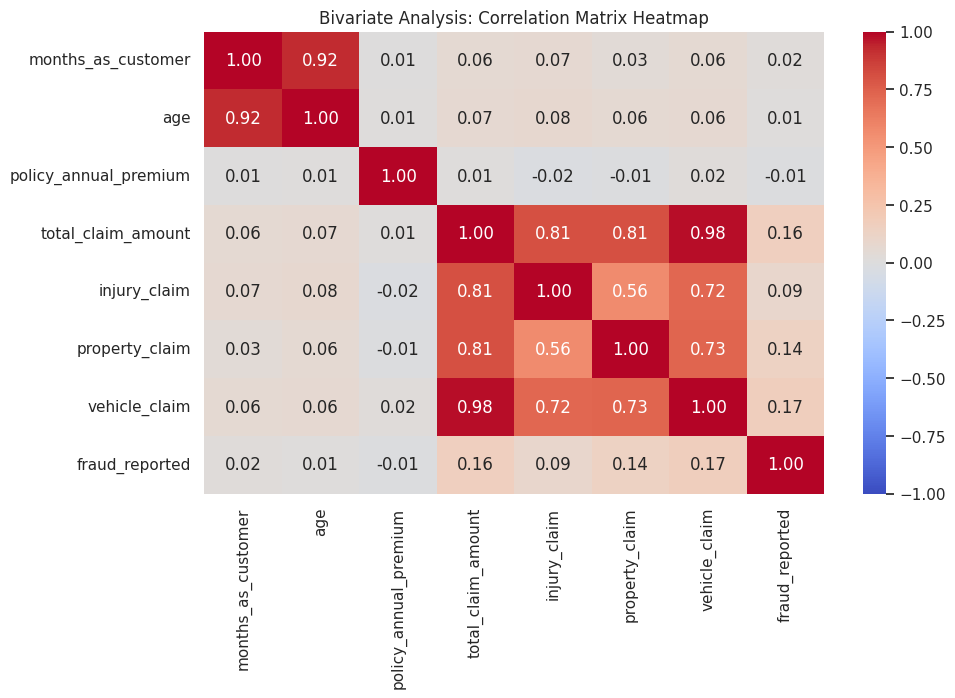

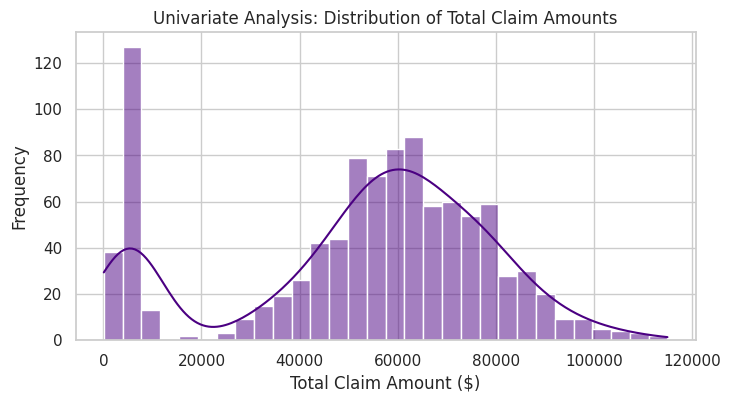

/tmp/ipykernel_8023/76997122.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='fraud_reported', y='total_claim_amount', data=df, palette='Set2')


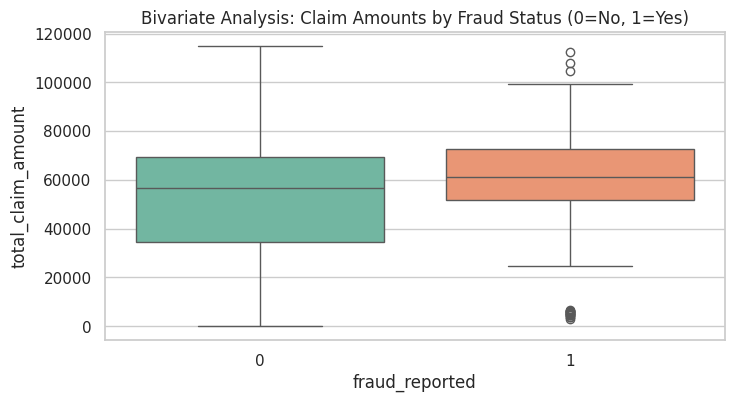

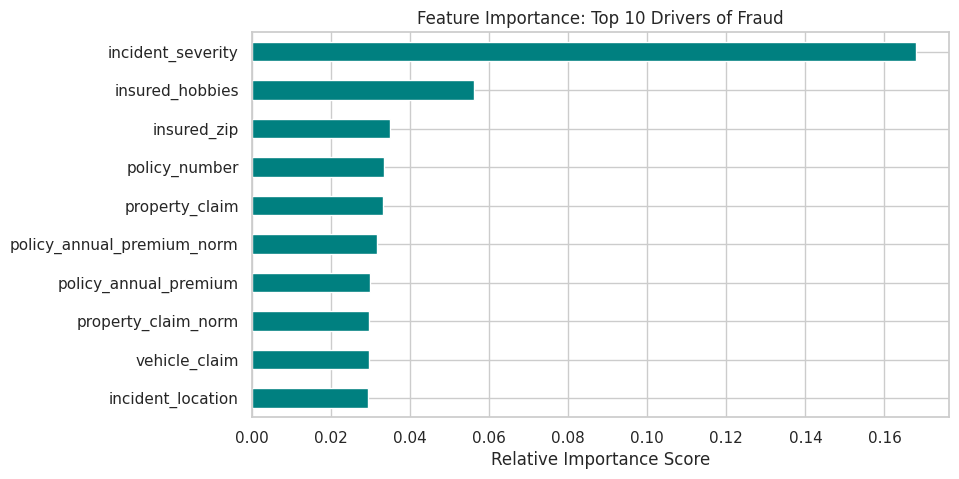

In [7]:
# Set a clean visual style for our charts
sns.set_theme(style="whitegrid")

# ---------------------------------------------------------
# 1. Binning (Categorizing continuous data)
# ---------------------------------------------------------
# Let's convert the continuous 'age' column into categorical age groups
bins = [18, 30, 45, 60, 100]
labels = ['18-30', '31-45', '46-60', '61+']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=True)
print("--- Result of Age Binning ---")
display(df[['age', 'age_group']].head())

# ---------------------------------------------------------
# 2. Encoding (Text to Numbers)
# ---------------------------------------------------------
# Convert the target variable 'fraud_reported' from 'Y'/'N' to 1/0
df['fraud_reported'] = df['fraud_reported'].map({'Y': 1, 'N': 0})

# Create a copy of the dataframe specifically for Machine Learning operations
encoded_df = df.copy()
encoder = LabelEncoder()

# Encode all remaining categorical text variables into numbers
for col in categorical_cols:
    if col in encoded_df.columns and col != 'fraud_reported':
        encoded_df[col] = encoder.fit_transform(encoded_df[col].astype(str))

# ---------------------------------------------------------
# 3. Correlation Coefficients & Bivariate Analysis
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))
# Select a subset of important numeric & encoded columns for a clean heatmap
corr_cols = ['months_as_customer', 'age', 'policy_annual_premium', 'total_claim_amount',
             'injury_claim', 'property_claim', 'vehicle_claim', 'fraud_reported']
corr_matrix = encoded_df[corr_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Bivariate Analysis: Correlation Matrix Heatmap')
plt.show()

# ---------------------------------------------------------
# 4. Univariate Visualizations
# ---------------------------------------------------------
plt.figure(figsize=(8, 4))
sns.histplot(df['total_claim_amount'], kde=True, color='indigo', bins=30)
plt.title('Univariate Analysis: Distribution of Total Claim Amounts')
plt.xlabel('Total Claim Amount ($)')
plt.ylabel('Frequency')
plt.show()

# ---------------------------------------------------------
# 5. Bivariate Visualizations
# ---------------------------------------------------------
plt.figure(figsize=(8, 4))
sns.boxplot(x='fraud_reported', y='total_claim_amount', data=df, palette='Set2')
plt.title('Bivariate Analysis: Claim Amounts by Fraud Status (0=No, 1=Yes)')
plt.show()

# ---------------------------------------------------------
# 6. Assessing Feature Importance
# ---------------------------------------------------------
# Prepare data for a Random Forest model (drop dates and text bins)
cols_to_drop = ['policy_bind_date', 'incident_date', 'age_group', 'fraud_reported']
X = encoded_df.drop(columns=cols_to_drop)
# Keep only numeric columns for the model
X = X.select_dtypes(include=['number'])
y = encoded_df['fraud_reported']

# Train a fast Random Forest classifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

# Extract and plot the Top 10 most important features for predicting fraud
importances = rf.feature_importances_
feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=False).head(10)

plt.figure(figsize=(9, 5))
feat_imp.plot(kind='barh', color='teal')
plt.gca().invert_yaxis() # Display highest importance at the top
plt.title('Feature Importance: Top 10 Drivers of Fraud')
plt.xlabel('Relative Importance Score')
plt.show()